Here we investigate the consequences of the severity screening threshold on our exceedance function. We consider the following situations:
1. Dropping data points below a screening threshold and fitting without acknowledging it.
2. Acknowledge the screening threshold as you fit.
3. Don't drop and fit.
4. With and without truncation of the distribution at the largest data point.

We will try both with the Marani et al. dataset and with synthetic data.

In [9]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import beta, genpareto

In [2]:
# Load data
marani_raw = pd.read_excel("../../data/raw/epidemics_marani_240816.xlsx")
marani_raw = marani_raw[marani_raw['year_start'].between(1600, 1945)]
marani_raw = marani_raw[marani_raw['death_thousand'] >= 0]
marani_raw['intensity'] = marani_raw['severity_perthousand'] / marani_raw['duration']

In [3]:
# Constants
MU_PRIME = 1e-3  # Deaths / thousand / year units
THRESH = MU_PRIME * 1e2

Text(0.5, 1.0, 'Empirical Exceedance Distribution')

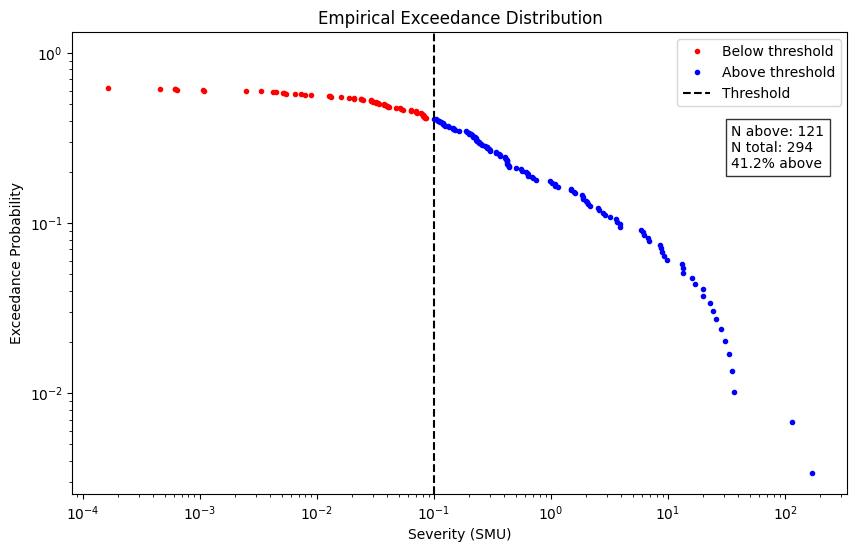

In [4]:
# Calculate number and percentage above threshold
# Calculate stats
n_above = len(marani_raw[marani_raw['severity_smu'] >= THRESH])
n_total = len(marani_raw)
pct_above = n_above * 100 / n_total

# Plot empirical exceedance
plt.figure(figsize=(10,6))
sorted_data = np.sort(marani_raw['severity_smu'].values)
emp_exceed = 1 - np.arange(1, len(sorted_data) + 1) / (len(sorted_data) + 1)

plt.plot(sorted_data[sorted_data < THRESH], 
         emp_exceed[sorted_data < THRESH],
         'r.', label='Below threshold')
plt.plot(sorted_data[sorted_data >= THRESH],
         emp_exceed[sorted_data >= THRESH], 
         'b.', label='Above threshold')
plt.axvline(x=THRESH, color='k', linestyle='--', label='Threshold')

# Add stats text
plt.text(0.85, 0.80, 
         f'N above: {n_above}\nN total: {n_total}\n{pct_above:.1f}% above',
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.8))

plt.xscale('log')
plt.yscale('log')
plt.ylabel('Exceedance Probability')
plt.xlabel('Severity (SMU)')
plt.legend()
plt.title('Empirical Exceedance Distribution')

In [5]:
def fit_distributions(data, loc_param, screen_thresh=None):
    """
    Fit GPD distributions to data with different threshold handling approaches.
    
    Args:
        data (pd.Series): Data to fit
        screen_thresh (float): Screening threshold for data filtering
        loc_param (float): Location parameter for GPD fit. If None, uses screen_thresh
        
    Returns:
        tuple: Fitted GPD parameters (shape, location, scale)
    """
    if screen_thresh is None:
      screen_thresh = loc_param
    else:
      assert(screen_thresh >= loc_param)

    filtered_data = data[data >= screen_thresh]
    return genpareto.fit(filtered_data, floc=loc_param)

In [6]:
def plot_exceedance_subplots(data, loc_param, screen_thresh):
    """
    Plot exceedance probability curves with given parameters in a two-panel subplot.
    
    Args:
        data (pd.Series): Original data
        loc_param (float): Location parameter for GPD fit
        screen_thresh (float): Screening threshold for data filtering
    """
    # Fit distributions with parameters
    params_no_ack = fit_distributions(data, loc_param)
    params_with_ack = fit_distributions(data, loc_param, screen_thresh=screen_thresh)
    
    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True, sharex=True)
    
    # Get common x range for all plots
    x = np.logspace(-4, 3, 10000)
    
    params_list = [params_no_ack, params_with_ack]
    screen_thresholds = [loc_param, screen_thresh]
    labels = ['Loc = Screen', 'Loc ≠ Screen']
    
    for ax, params, screen_thresh, label in zip(axes, params_list, screen_thresholds, labels):
        # Plot empirical exceedance for filtered data
        filtered_data = data[data >= screen_thresh]
        sorted_data = np.sort(filtered_data)
        emp_exceed = 1 - np.arange(1, len(filtered_data) + 1) / (len(filtered_data) + 1)
        ax.plot(sorted_data, emp_exceed, 'k.', label='Empirical', alpha=0.5)
        
        # Plot fitted curve
        exceed_prob = 1 - genpareto.cdf(x, *params)
        ax.plot(x, exceed_prob, label=f'Fitted ({label})')
        
        # Add threshold and location parameter lines
        ax.axvline(x=screen_thresh, color='r', linestyle='--', 
                  label='Screening Threshold', alpha=0.5)
        ax.axvline(x=params[1], color='g', linestyle=':', 
                  label=f'Location Parameter ({params[1]:.2f})', alpha=0.5)
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_ylabel('Exceedance Probability' if ax == axes[0] else '')
        ax.set_xlabel('Severity (SMU)')
        ax.set_title(label)
        ax.grid(True)
        ax.legend()
    
    plt.tight_layout()
    plt.show()


# Create interactive widgets
loc_slider = widgets.FloatLogSlider(
    value=0.1,
    base=10,
    min=-4, # min exponent of base
    max=1,  # max exponent of base
    step=0.1,
    description='Location Parameter:',
    continuous_update=False
)

screen_slider = widgets.FloatLogSlider(
    value=1.0,
    base=10,
    min=-4,
    max=1,
    step=0.1,
    description='Screen Threshold:',
    continuous_update=False
)

# Functions to update plots
def update_subplots(loc_param, screen_thresh):
    if screen_thresh < loc_param:
        print("Warning: Screen threshold must be >= location parameter")
        return
    plot_exceedance_subplots(marani_raw['severity_smu'], loc_param, screen_thresh)


# Create interactive plots
print("Subplot View:")
widgets.interactive(update_subplots, 
                   loc_param=loc_slider,
                   screen_thresh=screen_slider)


Subplot View:


interactive(children=(FloatLogSlider(value=0.1, continuous_update=False, description='Location Parameter:', ma…

In [7]:
def plot_comparison(data, loc_param, screen_thresh, fixed_rate=None):
    """
    Plot a single comparison of exceedance curves, with optional fixed arrival rate.
    
    Args:
        data (pd.Series): Original data from 1600-1945
        loc_param (float): Location parameter for GPD fit
        screen_thresh (float): Screening threshold for data filtering
        fixed_rate (float, optional): If provided, use this fixed annual arrival rate
                                    instead of empirically determined rates
    """
    # Calculate observation period and annual rate
    start_year = 1600
    end_year = 1945
    n_years = end_year - start_year + 1
    
    # Fit distributions with parameters
    params_loc_screen = fit_distributions(data, loc_param)
    params_high_screen = fit_distributions(data, loc_param, screen_thresh=screen_thresh)
    
    plt.figure(figsize=(10,6))
    ax = plt.gca()

    # Calculate empirical rates
    filtered_data = data[data >= loc_param]
    if fixed_rate is None:
        annual_rate_loc_screen = len(filtered_data) / n_years
        annual_rate_high_screen = len(filtered_data[filtered_data >= screen_thresh]) / n_years
    else:
        annual_rate_loc_screen = fixed_rate
        annual_rate_high_screen = fixed_rate
    
    sorted_data = np.sort(filtered_data)
    emp_exceed = (1 - np.arange(1, len(sorted_data) + 1) / (len(sorted_data) + 1)) * annual_rate_loc_screen
    ax.plot(sorted_data, emp_exceed, 'k.', label='Empirical', alpha=0.5)

    # Create x values for fitted curves
    x = np.logspace(np.log10(loc_param), np.log10(max(data)*1.1), 1000)

    # Plot both fitted curves with annual rate adjustment
    exceed_prob_loc_screen = (1 - genpareto.cdf(x, *params_loc_screen)) * annual_rate_loc_screen
    exceed_prob_high_screen = (1 - genpareto.cdf(x, *params_high_screen)) * annual_rate_high_screen
    ax.plot(x, exceed_prob_loc_screen, label='Loc = Screen')
    ax.plot(x, exceed_prob_high_screen, label='Loc < Screen')

    # Add vertical lines for thresholds and max observation
    ax.axvline(x=loc_param, color='g', linestyle=':', 
               label=f'Location Parameter ({loc_param:.2f})', alpha=0.5)
    ax.axvline(x=screen_thresh, color='r', linestyle='--', 
               label='Screening Threshold', alpha=0.5)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('Annual Exceedance Probability')
    ax.set_xlabel('Severity (SMU)')
    title = 'Direct Comparison of Different Threshold Approaches'
    if fixed_rate is not None:
        title += f'\n(Fixed Annual Rate: {fixed_rate:.3f})'
    else:
        title += '\n(Empirically Determined Annual Rates)'
    ax.set_title(title)
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()


def update_comparison(loc_param, screen_thresh, use_fixed_rate=False, fixed_rate=0.1):
    """
    Update the comparison plots based on location parameter, screening threshold and optional fixed rate.
    
    Args:
        loc_param (float): Location parameter for GPD
        screen_thresh (float): Screening threshold value
        use_fixed_rate (bool): Whether to use fixed rate or empirical rate
        fixed_rate (float): Fixed annual exceedance rate between 0 and 1
    """
    if screen_thresh < loc_param:
        print("Warning: Screen threshold must be >= location parameter")
        return
        
    # Plot with empirical or fixed rate
    plot_comparison(marani_raw['severity_smu'], loc_param, screen_thresh, 
                   fixed_rate if use_fixed_rate else None)


print("\nComparison View:")
# Create fixed rate widgets
fixed_rate_checkbox = widgets.Checkbox(
    value=False,
    description='Use Fixed Rate',
    layout=widgets.Layout(width='150px')
)

fixed_rate_value = widgets.FloatText(
    value=0.1,
    description='Rate:',
    min=0.0,
    max=1.0,
    step=0.001,
    disabled=True,
    layout=widgets.Layout(width='200px')
)

# Link the widgets
def on_checkbox_change(change):
    fixed_rate_value.disabled = not change.new

fixed_rate_checkbox.observe(on_checkbox_change, names='value')

# Create interactive plot with fixed rate logic
# Create a container for the widgets
controls = widgets.VBox([
    fixed_rate_checkbox,
    fixed_rate_value,
    widgets.interactive(
        update_comparison,
        loc_param=loc_slider,
        screen_thresh=screen_slider,
        use_fixed_rate=fixed_rate_checkbox,
        fixed_rate=fixed_rate_value
    )
])

display(controls)



Comparison View:


In [11]:
def sample_by_order_statistic(data, sample_ranges, seed=None):
    """
    Sample data points based on their position in the ordered dataset with different
    sampling rates for different ranges.
    
    Args:
        data (array-like): Input data to sample from
        sample_ranges (list of tuples): List of (start_pct, end_pct, sample_rate) tuples
            where percentages are in [0,1] and sample_rate is the probability of selection
        seed (int, optional): Random seed for reproducibility
    
    Returns:
        tuple: (sampled_indices, sampled_data)
    """
    if seed is not None:
        np.random.seed(seed)
        
    # Sort data and get indices that would sort it
    sorted_indices = np.argsort(data)
    n_points = len(data)
    
    # Initialize selection array
    selected = np.zeros(n_points, dtype=bool)
    
    # Apply sampling for each range
    for start_pct, end_pct, sample_rate in sample_ranges:
        start_idx = int(start_pct * n_points)
        end_idx = int(end_pct * n_points)
        range_indices = sorted_indices[start_idx:end_idx]
        
        # Randomly sample points in this range
        selections = np.random.random(len(range_indices)) < sample_rate
        selected[range_indices[selections]] = True
    
    return selected, data[selected]

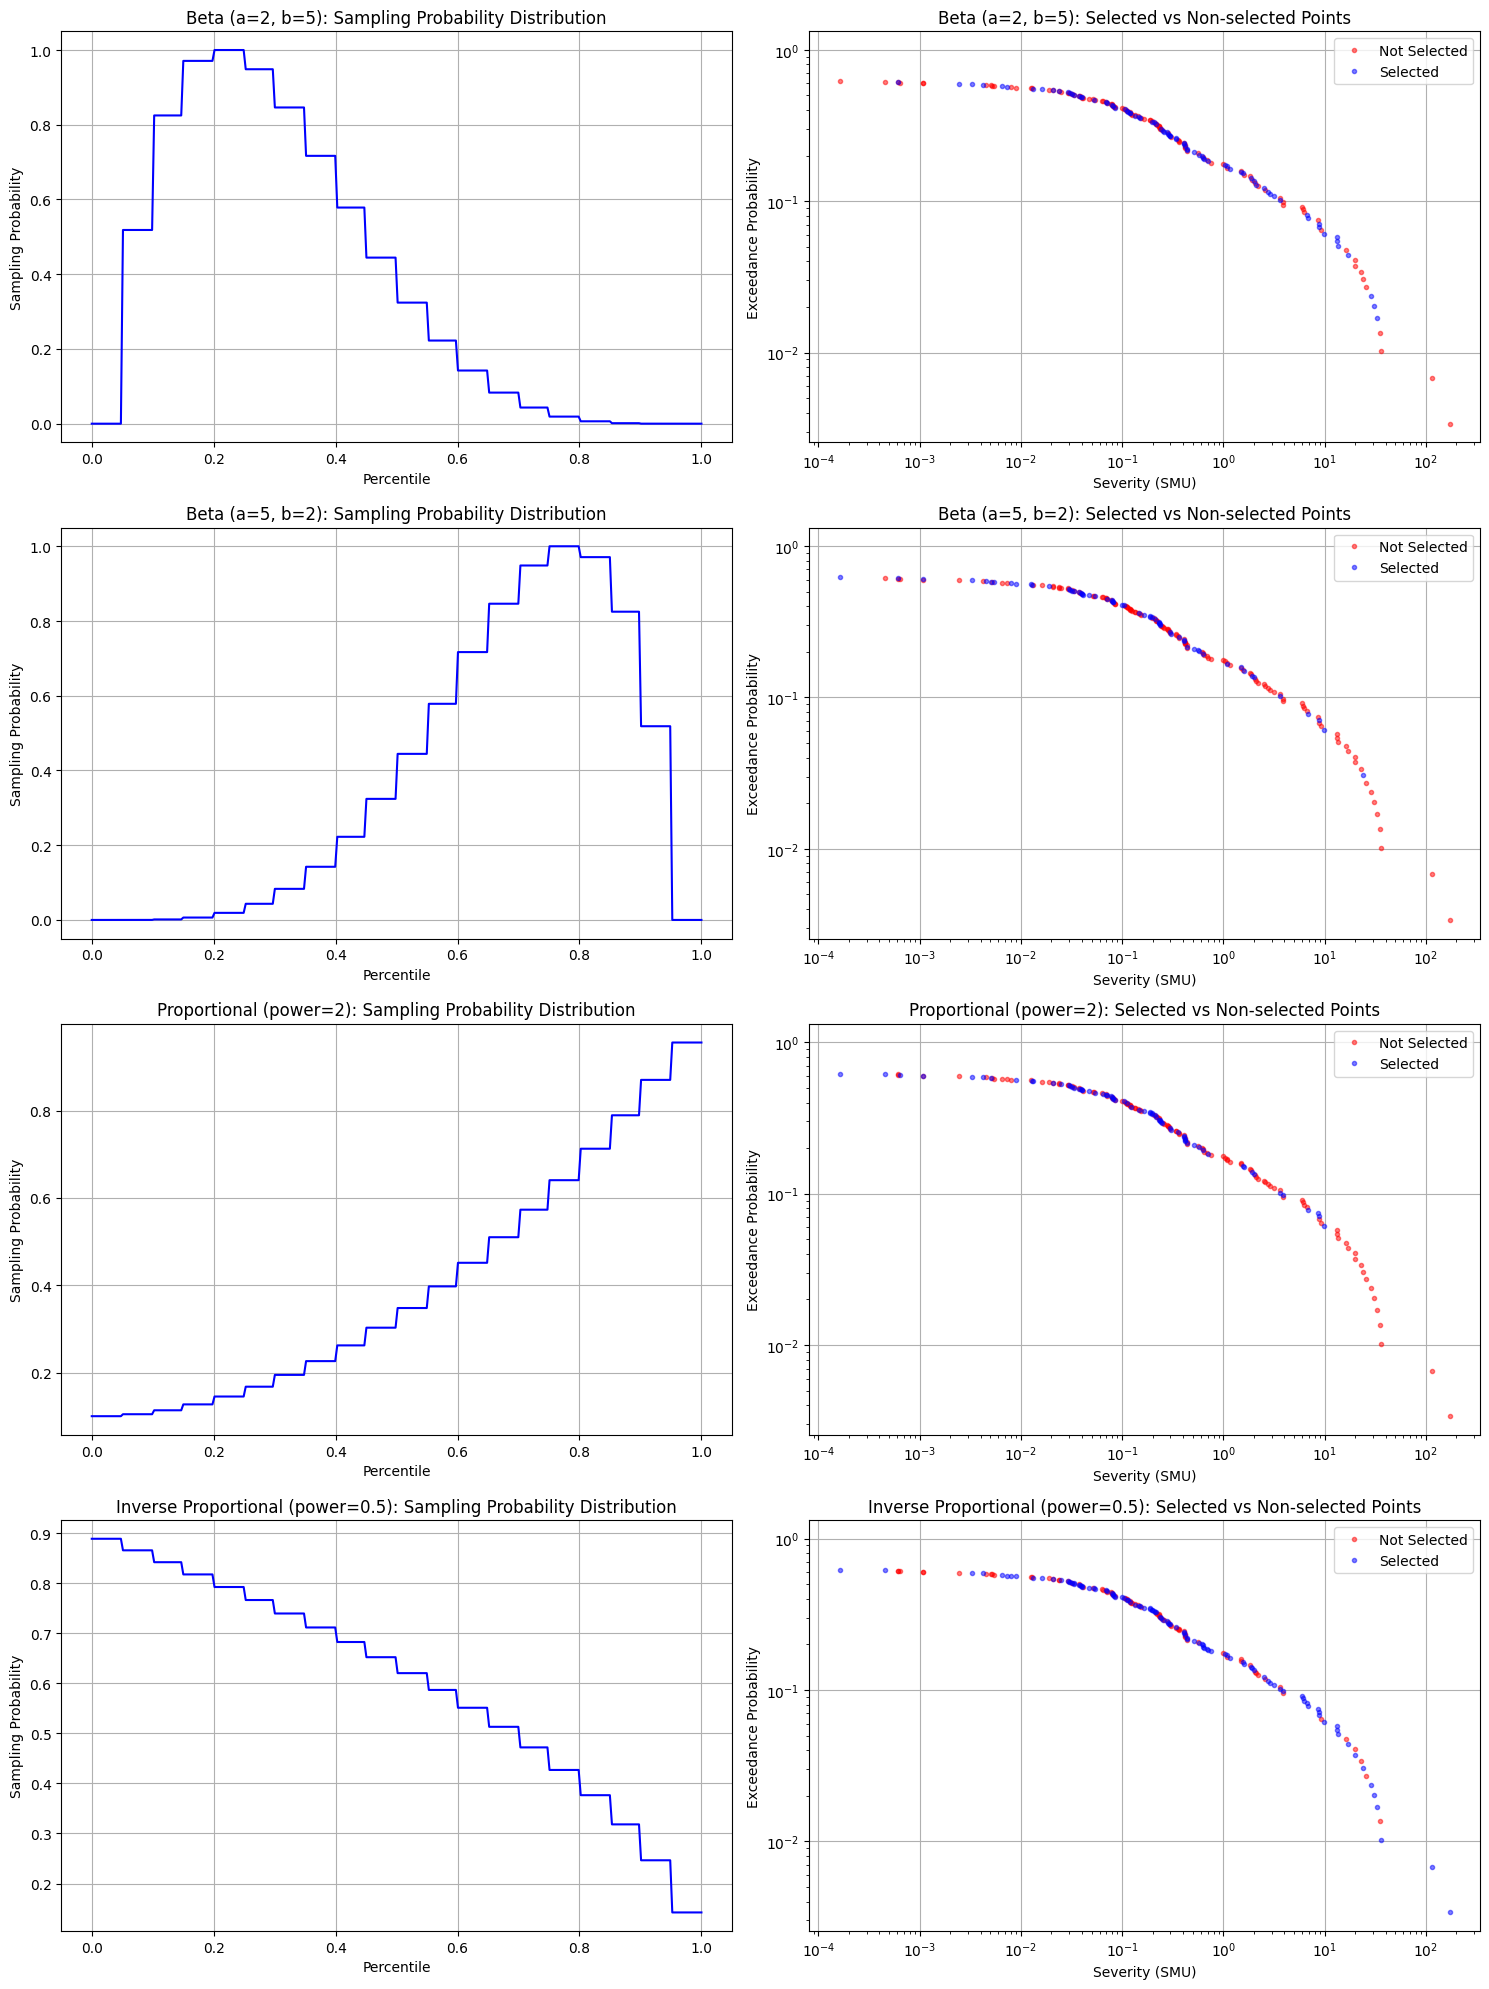


Beta (a=2, b=5):
Total points selected: 123 (41.8%)

Beta (a=5, b=2):
Total points selected: 109 (37.1%)

Proportional (power=2):
Total points selected: 119 (40.5%)

Inverse Proportional (power=0.5):
Total points selected: 171 (58.2%)


In [12]:
def generate_sample_ranges(n_ranges=20, method='beta', **kwargs):
    """
    Generate sample ranges using different probability distributions.
    
    Args:
        n_ranges (int): Number of ranges to generate
        method (str): Sampling method. Options:
            - 'beta': Beta distribution with parameters a, b
            - 'proportional': Sampling rate proportional to percentile
            - 'inverse_proportional': Sampling rate inversely proportional to percentile
        **kwargs:
            For beta:
                a (float): Alpha parameter
                b (float): Beta parameter
            For proportional/inverse_proportional:
                power (float): Power for scaling (default=1.0)
                min_rate (float): Minimum sampling rate (default=0.0)
                max_rate (float): Maximum sampling rate (default=1.0)
    
    Returns:
        list: List of (start_pct, end_pct, sample_rate) tuples
    """
    percentiles = np.linspace(0, 1, n_ranges + 1)
    ranges = []
    
    if method == 'beta':
        a = kwargs.get('a', 2)
        b = kwargs.get('b', 2)
        
        # Generate sample rates using beta distribution
        x = np.linspace(0, 1, n_ranges)
        rates = beta.pdf(x, a, b)
        # Normalize to [0,1]
        rates = (rates - rates.min()) / (rates.max() - rates.min())
        
    elif method in ['proportional', 'inverse_proportional']:
        power = kwargs.get('power', 1.0)
        min_rate = kwargs.get('min_rate', 0.0)
        max_rate = kwargs.get('max_rate', 1.0)
        
        # Generate midpoints of ranges
        x = (percentiles[1:] + percentiles[:-1]) / 2
        
        if method == 'proportional':
            rates = x ** power
        else:  # inverse_proportional
            rates = (1 - x) ** power
            
        # Scale to desired range
        rates = min_rate + (max_rate - min_rate) * rates
        
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Create ranges
    for i in range(n_ranges):
        ranges.append((percentiles[i], percentiles[i+1], rates[i]))
    
    return ranges

def plot_sampling_distributions(data, methods_config, seed=42):
    """
    Plot and compare different sampling distributions.
    
    Args:
        data (array-like): Data to sample from
        methods_config (dict): Dictionary of method configurations
            {name: (method, kwargs)}
        seed (int): Random seed
    """
    n_methods = len(methods_config)
    fig, axes = plt.subplots(n_methods, 2, figsize=(15, 5*n_methods))
    
    for i, (name, (method, kwargs)) in enumerate(methods_config.items()):
        # Generate sample ranges
        sample_ranges = generate_sample_ranges(method=method, **kwargs)
        
        # Apply sampling
        selected, sampled = sample_by_order_statistic(data, sample_ranges, seed=seed)
        
        # Get current row of axes
        ax1, ax2 = axes[i] if n_methods > 1 else axes
        
        # Plot sampling probability distribution
        percentiles = np.linspace(0, 1, len(data))
        sampling_prob = np.zeros_like(percentiles)
        for start_pct, end_pct, sample_rate in sample_ranges:
            mask = (percentiles >= start_pct) & (percentiles <= end_pct)
            sampling_prob[mask] = sample_rate
        
        ax1.plot(percentiles, sampling_prob, 'b-')
        ax1.set_xlabel('Percentile')
        ax1.set_ylabel('Sampling Probability')
        ax1.set_title(f'{name}: Sampling Probability Distribution')
        ax1.grid(True)
        
        # Plot selected vs non-selected points
        sorted_data = np.sort(data)
        emp_exceed = 1 - np.arange(1, len(sorted_data) + 1) / (len(sorted_data) + 1)
        
        ax2.plot(sorted_data[~selected], emp_exceed[~selected], 'r.', 
                label='Not Selected', alpha=0.5)
        ax2.plot(sorted_data[selected], emp_exceed[selected], 'b.', 
                label='Selected', alpha=0.5)
        
        ax2.set_xscale('log')
        ax2.set_yscale('log')
        ax2.set_xlabel('Severity (SMU)')
        ax2.set_ylabel('Exceedance Probability')
        ax2.set_title(f'{name}: Selected vs Non-selected Points')
        ax2.grid(True)
        ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print sampling statistics
    for name, (method, kwargs) in methods_config.items():
        sample_ranges = generate_sample_ranges(method=method, **kwargs)
        selected, _ = sample_by_order_statistic(data, sample_ranges, seed=seed)
        print(f"\n{name}:")
        print(f"Total points selected: {selected.sum()} ({100*selected.sum()/len(data):.1f}%)")

# Example usage with different distributions
methods_config = {
    'Beta (a=2, b=5)': ('beta', {'a': 2, 'b': 5}),
    'Beta (a=5, b=2)': ('beta', {'a': 5, 'b': 2}),
    'Proportional (power=2)': ('proportional', {'power': 2, 'min_rate': 0.1}),
    'Inverse Proportional (power=0.5)': ('inverse_proportional', {'power': 0.5, 'max_rate': 0.9})
}

# Plot all distributions
plot_sampling_distributions(marani_raw['severity_smu'].values, methods_config)

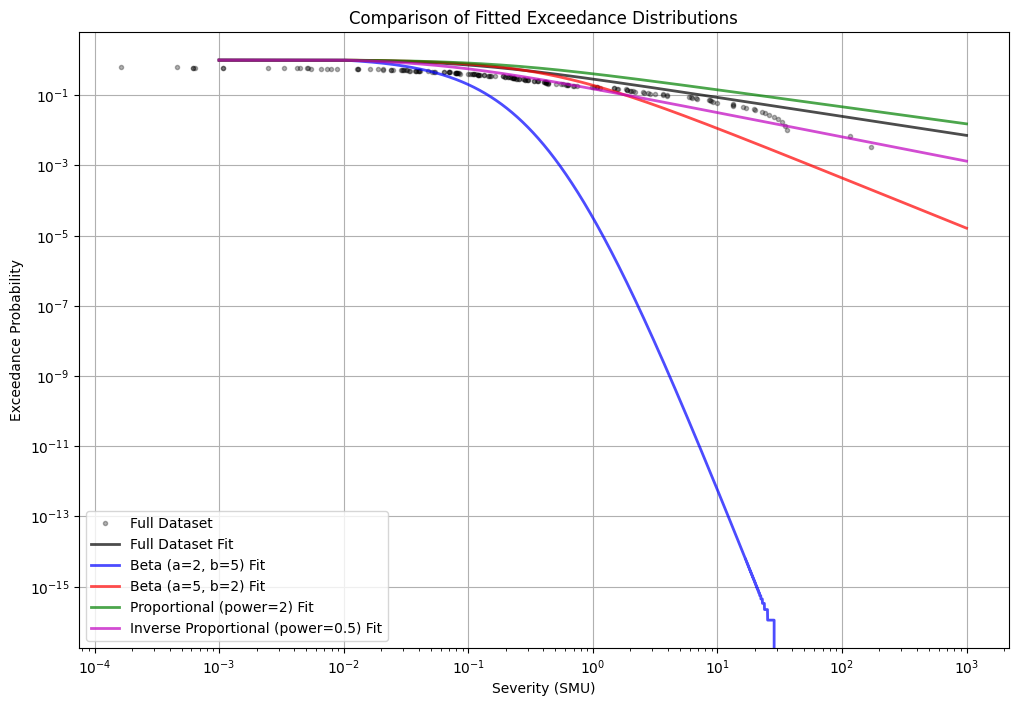


Fitted GPD Parameters (shape, location, scale):
Full dataset: (np.float64(1.843572386556619), 0.01, np.float64(0.20519611855488934))
Beta (a=2, b=5): (np.float64(1.1396342408628717), np.float64(0.0), np.float64(3.005183064534128e-29))
Beta (a=5, b=2): (np.float64(0.7584463671399794), np.float64(0.0), np.float64(0.2774757473163644))
Proportional (power=2): (np.float64(7.237458092089042), np.float64(0.0), np.float64(2.0384607059498422e-27))
Inverse Proportional (power=0.5): (np.float64(1.3788451610214099), np.float64(0.0), np.float64(5.68752187713203e-31))


In [16]:
# Function to compare exceedance distributions with different sampling methods
def compare_exceedance_fits(data, methods_config, seed=42):
    """
    Compare fitted exceedance distributions for different sampling methods.
    
    Args:
        data (array-like): Input severity data
        methods_config (dict): Dictionary of sampling methods and their parameters
        seed (int): Random seed for reproducibility
    """
    plt.figure(figsize=(12, 8))
    THRESH = 0.01
    
    # Calculate empirical exceedance for full dataset
    sorted_data = np.sort(data)
    emp_exceed = 1 - np.arange(1, len(sorted_data) + 1) / (len(sorted_data) + 1)
    
    # Plot full dataset and fit
    plt.plot(sorted_data, emp_exceed, 'k.', label='Full Dataset', alpha=0.3)
    params_full = fit_distributions(data, THRESH)
    x_fit = np.logspace(-3, 3, 10000)
    y_fit = 1 - genpareto.cdf(x_fit, *params_full)
    plt.plot(x_fit, y_fit, 'k-', label='Full Dataset Fit', linewidth=2, alpha=0.7)
    
    # Fit and plot for each sampling method
    colors = ['b', 'r', 'g', 'm']
    for (name, (method, kwargs)), color in zip(methods_config.items(), colors):
        # Get sampled points
        sample_ranges = generate_sample_ranges(method=method, **kwargs)
        selected, _ = sample_by_order_statistic(data, sample_ranges, seed=seed)
        
        # Get sampled data
        sampled_data = data[selected]
        
        # Fit GPD to sampled data
        params = fit_distributions(sampled_data, THRESH)
        
        # Generate points for fitted distribution
        y_fit = 1 - genpareto.cdf(x_fit, *params)
        
        plt.plot(x_fit, y_fit, f'{color}-', label=f'{name} Fit', linewidth=2, alpha=0.7)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Severity (SMU)')
    plt.ylabel('Exceedance Probability')
    plt.title('Comparison of Fitted Exceedance Distributions')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    # Print fit parameters for each method
    print("\nFitted GPD Parameters (shape, location, scale):")
    print("Full dataset:", params_full)
    
    for name, (method, kwargs) in methods_config.items():
        sample_ranges = generate_sample_ranges(method=method, **kwargs)
        selected, _ = sample_by_order_statistic(data, sample_ranges, seed=seed)
        sampled_data = data[selected]
        params = fit_distributions(sampled_data, sampled_data.min())
        print(f"{name}:", params)

# Compare exceedance distributions
compare_exceedance_fits(marani_raw['severity_smu'].values, methods_config)

